<a href="https://colab.research.google.com/github/rishikaa177/APS-Lab/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sample Input: [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sorted output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
------------------------------


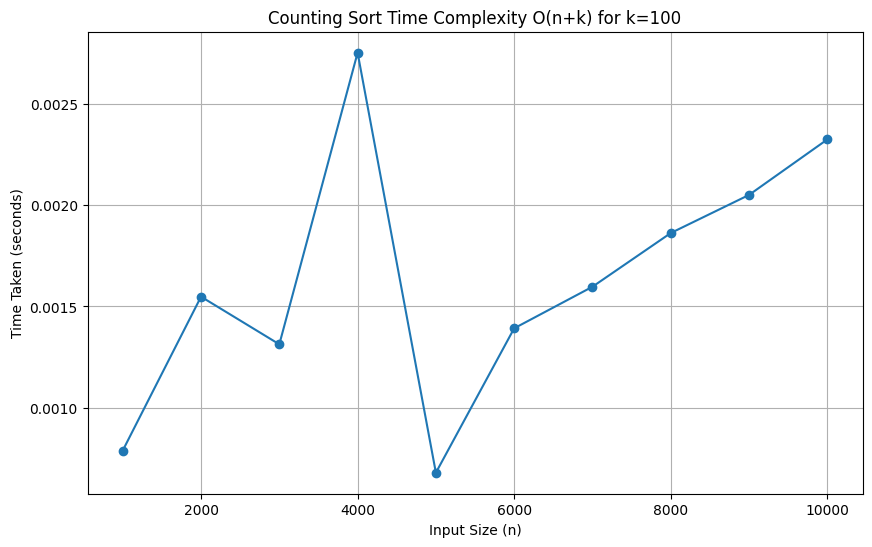

In [2]:
#write code for above cell and compute the running time and also plot graph.
import random
import time
import matplotlib.pyplot as plt

def counting_sort(arr):
  if not arr:
    return []

  # Ensure elements are non-negative for this implementation of Counting Sort
  # If negative numbers are possible, a different approach or adjustment is needed
  # (e.g., shifting all numbers by the absolute value of the minimum, sorting, then shifting back).
  # For the given problem statement and sample, inputs are non-negative.
  if min(arr) < 0:
      raise ValueError("Counting sort as implemented here does not handle negative numbers.")

  max_val = max(arr)
  count = [0] * (max_val + 1)

  # Fill the count array
  for num in arr:
    count[num] += 1

  # Reconstruct the sorted array
  sorted_arr = []
  for i in range(len(count)):
    while count[i] > 0:
      sorted_arr.append(i)
      count[i] -= 1
  return sorted_arr

# Sample Input and Output demonstration
sample_input = [4,3,2,1,4,3,2,4,3,4]
print("Sample Input:", sample_input)
sorted_sample_output = counting_sort(sample_input)
print("Sorted output:", sorted_sample_output)
print("-" * 30) # Separator for clarity

# Time Complexity Analysis and Plotting
sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
times = []
# Assuming k is approximately 100 based on random.randint(0,100)
max_val_for_benchmark = 100

for n in sizes:
  # Generate an array of size n with random integers between 0 and max_val_for_benchmark
  arr = [random.randint(0, max_val_for_benchmark) for _ in range(n)]
  start = time.time()
  counting_sort(arr) # Call the sorting function
  end = time.time()
  times.append(end - start)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o', linestyle='-')
plt.xlabel("Input Size (n)")
plt.ylabel("Time Taken (seconds)")
plt.title(f"Counting Sort Time Complexity O(n+k) for k={max_val_for_benchmark}")
plt.grid(True)
plt.show()

 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sorted Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
------------------------------


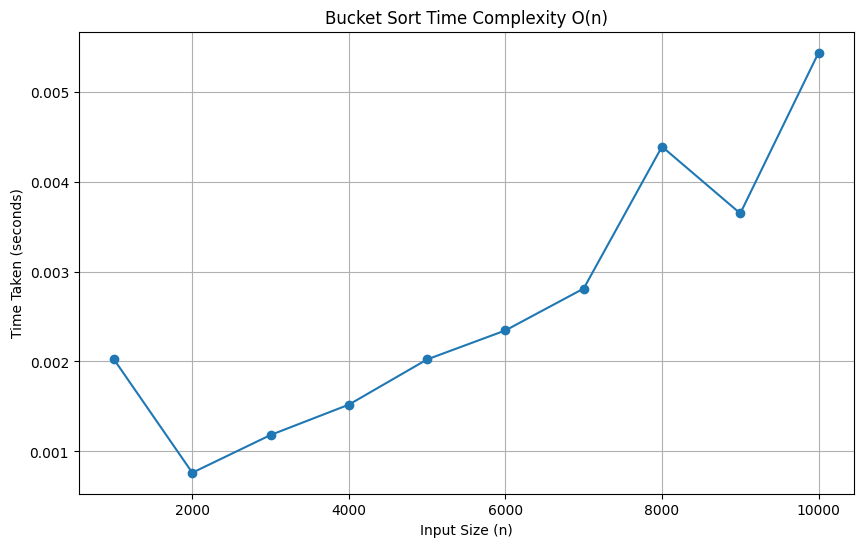

In [4]:
#write code for above cell and compute the running time and also plot graph.
import random
import time
import matplotlib.pyplot as plt

def bucket_sort(arr):
  if not arr:
    return []

  max_val = max(arr)
  min_val = min(arr)

  # Handle edge case where all elements are the same (e.g., all zeros)
  if max_val == min_val:
      return sorted(arr) # Or just return arr if it's already considered 'sorted' for this case

  # A heuristic for bucket count, could be tuned
  bucket_count = len(arr)
  if bucket_count == 0: # Ensure at least one bucket if array is very small but not empty
      bucket_count = 1

  buckets = [[] for _ in range(bucket_count)]

  # Fill buckets
  for num in arr:
    # Normalize num to be between 0 and 1, then scale to bucket_count
    # Using max_val + 1 to ensure index doesn't go out of bounds when num == max_val
    index = int((num - min_val) * bucket_count / (max_val - min_val + 1))
    buckets[index].append(num)

  # Sort buckets and concatenate
  sorted_arr = []
  for bucket in buckets:
    bucket.sort() # Sort elements within each bucket in-place
    sorted_arr.extend(bucket) # Extend the final sorted array with sorted bucket elements
  return sorted_arr

# Sample Input and Output demonstration
sample_input=[8,5,3,1,9,6,0,7,4,2,5]
print("Sample Input:", sample_input)
print("Sorted Output:", bucket_sort(sample_input))
print("-" * 30) # Separator for clarity

# Time Complexity Analysis and Plotting
sizes=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]
times = [] # Corrected syntax: was times[]

# Using a fixed range for values to ensure k is somewhat constant for benchmarking
max_val_for_benchmark = 100
min_val_for_benchmark = 0

for n in sizes:
  arr=[random.randint(min_val_for_benchmark, max_val_for_benchmark) for _ in range(n)]
  start=time.time()
  bucket_sort(arr)
  end=time.time()
  times.append(end-start) # Corrected indentation: moved into the loop

plt.figure(figsize=(10, 6))
plt.plot(sizes,times, marker='o', linestyle='-') # Corrected variable: was size, should be sizes
plt.xlabel("Input Size (n)")
plt.ylabel("Time Taken (seconds)")
plt.title("Bucket Sort Time Complexity O(n)")
plt.grid(True)
plt.show()

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sample Input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sorted Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
------------------------------


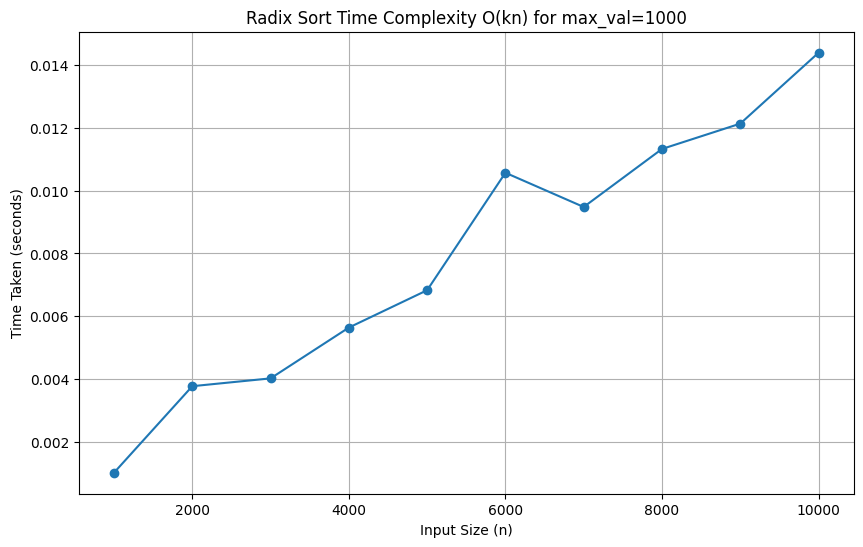

In [6]:
#write code for above cell and compute the running time and also plot graph.
import random
import time
import matplotlib.pyplot as plt

def counting_sort_for_radix(arr, exp):
  n = len(arr)
  output = [0] * n
  count = [0] * 10

  # Store count of occurrences in count[]
  for i in range(n):
    index = (arr[i] // exp) % 10 # Use integer division
    count[index] += 1

  # Change count[i] so that count[i] now contains actual
  # position of this digit in output array
  for i in range(1, 10):
    count[i] += count[i - 1]

  # Build the output array
  i = n - 1
  while i >= 0:
    index = (arr[i] // exp) % 10
    output[count[index] - 1] = arr[i]
    count[index] -= 1
    i -= 1

  # Copying the output array to arr[],
  # so that arr now contains sorted numbers according to current digit
  for i in range(n):
    arr[i] = output[i]

def radix_sort(arr):
  if len(arr) == 0:
    return arr

  # Find the maximum number to know number of digits
  max_val = max(arr)

  # Do counting sort for every digit. Note that instead of passing digit number,
  # exp is passed. exp is 10^i where i is current digit number
  exp = 1
  while max_val // exp > 0:
    counting_sort_for_radix(arr, exp)
    exp *= 10
  return arr

# Sample Input and Output demonstration
sample_input = [18,5,100,3,1,19,6,0,7,4,2]
print("Sample Input:", sample_input)
sorted_output = radix_sort(sample_input.copy()) # Corrected print syntax
print("Sorted Output:", sorted_output)
print("-" * 30) # Separator for clarity

# Time Complexity Analysis and Plotting
sizes = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]
times = [] # Corrected syntax

# Assuming numbers are within a range (e.g., 0 to 10000 for realistic 'k' - number of digits)
# For numbers up to 100, k will be small (2-3 digits), making it very fast.
# Let's use a slightly larger range to see a more pronounced k effect if needed, or keep to 100 as in other examples
max_val_for_benchmark = 1000 # Max value for random numbers to influence 'k'

for n in sizes:
  arr = [random.randint(0, max_val_for_benchmark) for _ in range(n)]
  start = time.time()
  radix_sort(arr.copy())
  end = time.time()
  times.append(end - start)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(sizes,times, marker='o', linestyle='-')
plt.xlabel("Input Size (n)")
plt.ylabel("Time Taken (seconds)")
plt.title(f"Radix Sort Time Complexity O(kn) for max_val={max_val_for_benchmark}") # Corrected title syntax
plt.grid(True)
plt.show()